In [1]:
# Import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
print("libraries loaded successfully!")

libraries loaded successfully!


In [3]:
# Load Dataset
df = pd.read_csv(r"C:\Users\Dessy\Downloads\nigerian loan default dataset.csv")
print("shape:", df.shape)
df.head()

shape: (1000, 13)


,applicant_name,gender,age,state,employment_type,monthly_income_naira,loan_amount_naira,loan_purpose,loan_tenure_months,credit_score,previous_default,collateral_type,loan_default
0,Kabir Okafor,Male,33,Ondo,Trader,165203,552264,Business Capital,12,634,0,Land,0
1,Emeka Adebayo,Female,37,Lagos,Trader,277908,3396145,Vehicle Purchase,48,668,0,Vehicle,0
2,Aisha Eze,Female,45,Rivers,Trader,336969,989695,Vehicle Purchase,12,348,1,NaN,0
3,Yusuf Okafor,Female,40,Rivers,Farmer,303493,2233955,Business Capital,36,351,0,Vehicle,1
4,Nneka Okeke,Male,29,Anambra,Salary Earner,222003,1302390,Business Capital,60,588,1,NaN,1


In [4]:
# basic info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   applicant_name        1000 non-null   str  
 1   gender                1000 non-null   str  
 2   age                   1000 non-null   int64
 3   state                 1000 non-null   str  
 4   employment_type       1000 non-null   str  
 5   monthly_income_naira  1000 non-null   int64
 6   loan_amount_naira     1000 non-null   int64
 7   loan_purpose          1000 non-null   str  
 8   loan_tenure_months    1000 non-null   int64
 9   credit_score          1000 non-null   int64
 10  previous_default      1000 non-null   int64
 11  collateral_type       864 non-null    str  
 12  loan_default          1000 non-null   int64
dtypes: int64(7), str(6)
memory usage: 101.7 KB


In [5]:
# checking missing value
df.isnull().sum()

applicant_name            0
gender                    0
age                       0
state                     0
employment_type           0
monthly_income_naira      0
loan_amount_naira         0
loan_purpose              0
loan_tenure_months        0
credit_score              0
previous_default          0
collateral_type         136
loan_default              0
dtype: int64

In [6]:
# Summary Statistics
df.describe()

,age,monthly_income_naira,loan_amount_naira,loan_tenure_months,credit_score,previous_default,loan_default
count,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.00000,1000.000000
mean,42.633000,266014.178000,2.502310e+06,29.160000,570.759000,0.24300,0.407000
std,12.218986,132677.605903,1.404501e+06,18.043391,158.342253,0.42911,0.491521
min,22.000000,30320.000000,5.021500e+04,6.000000,300.000000,0.00000,0.000000
25%,32.000000,152011.000000,1.347752e+06,12.000000,429.000000,0.00000,0.000000
50%,42.000000,266433.000000,2.460804e+06,24.000000,569.000000,0.00000,0.000000
75%,53.000000,376942.500000,3.750915e+06,48.000000,703.000000,0.00000,1.000000
max,64.000000,499690.000000,4.998122e+06,60.000000,849.000000,1.00000,1.000000


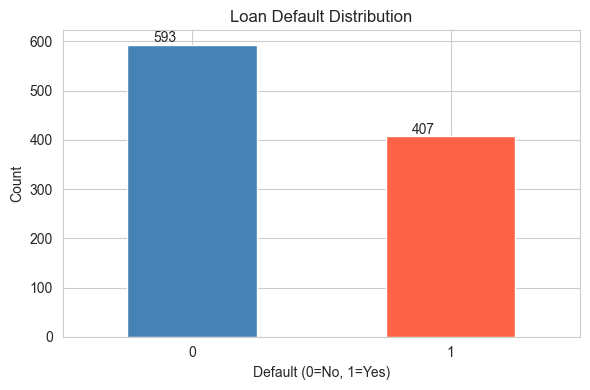

In [ ]:
# Target Variable Distribution
ax = df['loan_default'].value_counts().plot(kind='bar', color=['steelblue','tomato'], figsize=(6,4))
plt.title('Loan Default Distribution')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x()+0.1, p.get_height()+5))
plt.tight_layout()
plt.show()

C:\Users\Dessy\AppData\Local\Temp\ipykernel_4356\1827388682.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='employment_type', y='loan_default', data=df, palette='coolwarm')


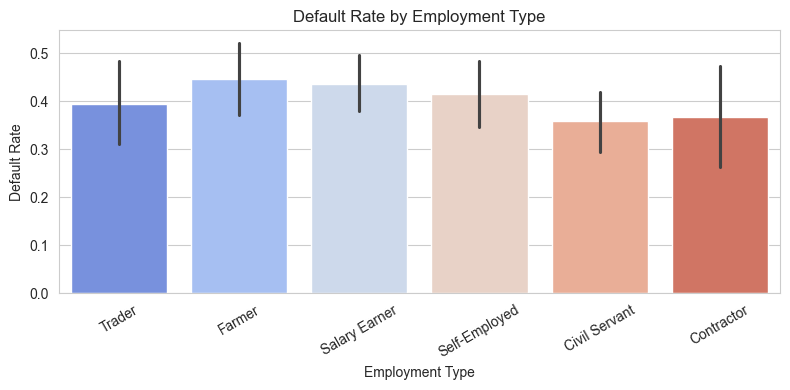

In [8]:
plt.figure(figsize=(8,4))
sns.barplot(x='employment_type', y='loan_default', data=df, palette='coolwarm')
plt.title('Default Rate by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Default Rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\Dessy\AppData\Local\Temp\ipykernel_4356\1184896993.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_default', y='credit_score', data=df, palette='Set2')


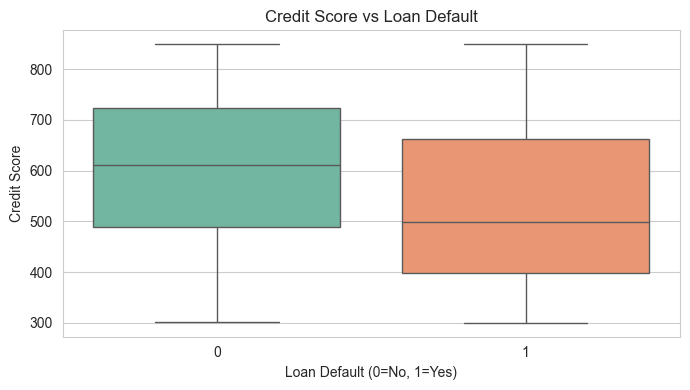

In [9]:
plt.figure(figsize=(7,4))
sns.boxplot(x='loan_default', y='credit_score', data=df, palette='Set2')
plt.title('Credit Score vs Loan Default')
plt.xlabel('Loan Default (0=No, 1=Yes)')
plt.ylabel('Credit Score')
plt.tight_layout()
plt.show()

In [10]:
# Drop columns not needed
df = df.drop(columns=['applicant_name'])
print("Columns after drop:", df.columns.tolist())


Columns after drop: ['gender', 'age', 'state', 'employment_type', 'monthly_income_naira', 'loan_amount_naira', 'loan_purpose', 'loan_tenure_months', 'credit_score', 'previous_default', 'collateral_type', 'loan_default']


In [11]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

cat_cols = ['gender', 'state', 'employment_type', 'loan_purpose', 'collateral_type']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding done!")
df.head()

Encoding done!


,gender,age,state,employment_type,monthly_income_naira,loan_amount_naira,loan_purpose,loan_tenure_months,credit_score,previous_default,collateral_type,loan_default
0,1,33,15,5,165203,552264,2,12,634,0,2,0
1,0,37,12,5,277908,3396145,6,48,668,0,3,0
2,0,45,19,5,336969,989695,6,12,348,1,4,0
3,0,40,19,2,303493,2233955,2,36,351,0,3,1
4,1,29,1,3,222003,1302390,2,60,588,1,4,1


In [13]:
# split features and target
X = df.drop(columns=['loan_default'])
y = df['loan_default']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 11)
Target shape: (1000,)


In [14]:
# slpit into test and train set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (800, 11)
Test set: (200, 11)


In [20]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=5000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.67
              precision    recall  f1-score   support

           0       0.69      0.81      0.74       119
           1       0.62      0.47      0.54        81

    accuracy                           0.67       200
   macro avg       0.66      0.64      0.64       200
weighted avg       0.66      0.67      0.66       200



c:\Users\Dessy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.645

               precision    recall  f1-score   support

           0       0.68      0.77      0.72       119
           1       0.58      0.46      0.51        81

    accuracy                           0.65       200
   macro avg       0.63      0.61      0.62       200
weighted avg       0.64      0.65      0.64       200



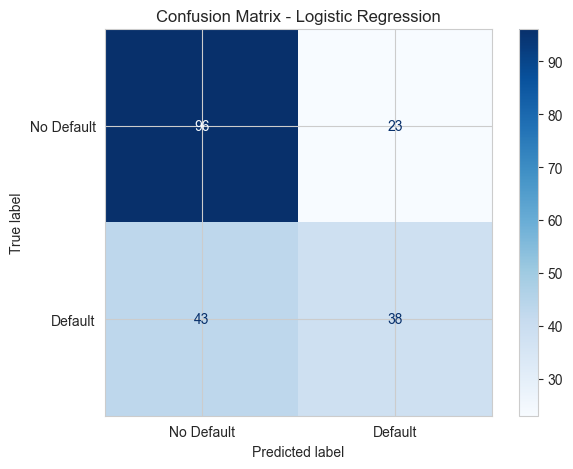

In [18]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

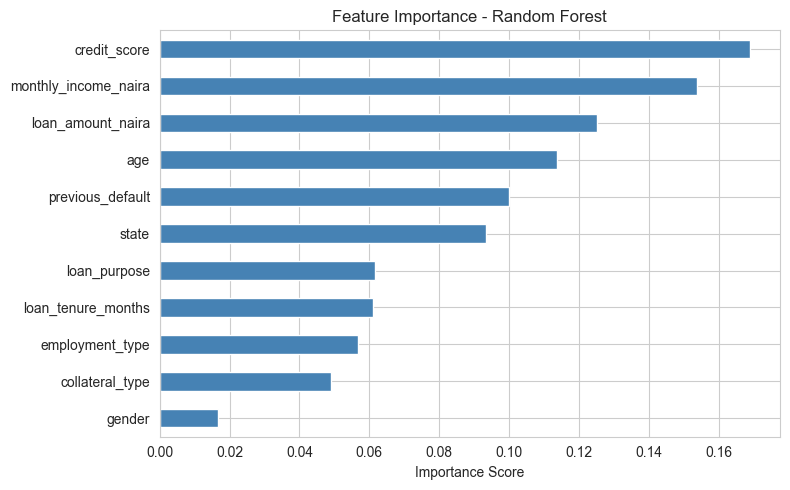

In [19]:
# # Feature Importance(Random Forest)
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [21]:
import joblib as jb
jb.dump(rf_model, "Default_model.pki")

['Default_model.pki']